### Process Mining Model Comparison 
Picks a final model from the heuristic + inductive grid search CSVs, scored for downstream BPMN conversion and decision mining on XOR splits.

 #### Selection logic:
   1. Drop models with precision < MIN_PRECISION or fitness < MIN_FITNESS.
   2. Rank survivors by a composite DM Score: DM = F-Score(fit, prec) × algo_bonus × cyclicity_factor × size_factor where:
        - F-Score is the harmonic mean of fitness and precision (primary signal).
        - algo_bonus favours inductive miner (process trees -> sound block-structured
          BPMN with explicit XOR gateways; heuristic nets aren't guaranteed sound).
        - cyclicity_factor = 1 - CYCLICITY_WEIGHT × cyclicity. Loops complicate
          XOR analysis, so high-cyclicity models are penalised.
        - size_factor    = 1 - SIZE_WEIGHT × normalized_total_size. Smaller models are easier to interpret and yield cleaner decision points.
      Tune the weights at the top; all factors are 1.0 when ideal.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pm4py

Loaded 283 rows across 5 log slices


**Gates:** precision ≥ 0.8, fitness ≥ 0.8 &nbsp;&nbsp; **Weights:** inductive×1.0, cyclicity=0.25, size=0.15

**Filtering:** 59 unique models &nbsp;|&nbsp; 24 disqualified for low precision &nbsp;|&nbsp; 0 disqualified for low fitness &nbsp;|&nbsp; **38 qualified for ranking**

## Top 10 by decision-mining suitability

Model Name,Algorithm,Variant Filter,Average Trace Fitness,Precision,Generalization,F-Score,Cyc Factor,Size Factor,DM Score,Node Size,Arc Size,Cyclicity
ind_top100_noise_0.90,inductive,top100,0.8477,0.9205,0.9211,0.8826,0.9231,0.9848,0.8023,52,58,0.3077
ind_top610_noise_0.90,inductive,top610,0.8485,0.9060,0.8817,0.8763,0.8929,1.0000,0.7824,42,46,0.4286
ind_top100_noise_0.60,inductive,top100,0.8697,0.8486,0.9258,0.8590,0.9182,0.9800,0.7729,55,62,0.3273
ind_top100_noise_0.50,inductive,top100,0.9063,0.8241,0.9318,0.8633,0.9195,0.9730,0.7724,59,68,0.3220
ind_top100_noise_0.40,inductive,top100,0.9329,0.8015,0.9241,0.8622,0.9087,0.9834,0.7704,52,60,0.3654
ind_top100_noise_0.99,inductive,top100,0.8182,0.9221,0.9206,0.8670,0.9018,0.9779,0.7646,56,64,0.3929
heu_top100_dep_0.30_and_0.90_loop_0.30,heuristic,top100,0.9256,0.9782,0.9880,0.9512,0.8284,0.9558,0.7531,67,85,0.6866
heu_top100_dep_0.90_and_0.90_loop_0.30,heuristic,top100,0.9271,0.9773,0.9869,0.9516,0.8272,0.9537,0.7507,68,87,0.6912
heu_top100_dep_0.30_and_0.95_loop_0.30,heuristic,top100,0.9373,0.9280,0.9877,0.9326,0.8333,0.9530,0.7406,69,87,0.6667
heu_top100_dep_0.90_and_0.95_loop_0.30,heuristic,top100,0.9388,0.9295,0.9866,0.9341,0.8321,0.9509,0.7392,70,89,0.6714


...

,Model Name,Algorithm,Variant Filter,Average Trace Fitness,Precision,Generalization,F-Score,Cyc Factor,Size Factor,DM Score,Node Size,Arc Size,Cyclicity
0,ind_top100_noise_0.90,inductive,top100,0.847736,0.920501,0.921052,0.882621,0.923077,0.984793,0.802337,52,58,0.307692
1,ind_top100_noise_0.60,inductive,top100,0.869735,0.848598,0.925840,0.859037,0.918182,0.979954,0.772940,55,62,0.327273
2,ind_top100_noise_0.50,inductive,top100,0.906322,0.824103,0.931791,0.863259,0.919492,0.973041,0.772361,59,68,0.322034


**inductive / top610**

,Model Name,Algorithm,Variant Filter,Average Trace Fitness,Precision,Generalization,F-Score,Cyc Factor,Size Factor,DM Score,Node Size,Arc Size,Cyclicity
0,ind_top610_noise_0.90,inductive,top610,0.8485,0.905956,0.881722,0.876287,0.892857,1.0,0.782399,42,46,0.428571


## Recommended final model


| Field | Value |
|---|---|
| **Model** | `ind_top100_noise_0.90` |
| Algorithm | `inductive` on `top100` |
| Fitness | 0.8477 |
| Precision | 0.9205 |
| Generalization | 0.9211 |
| F-Score | 0.8826 |
| Cyclicity Factor | 0.9231 (cyclicity = 0.3077) |
| Size Factor | 0.9848 (52 nodes + 58 arcs) |
| **DM Score** | **0.8023** |

*Runner-up:* `ind_top610_noise_0.90` (DM Score 0.7824, fitness 0.848, precision 0.906, cyclicity 0.429)

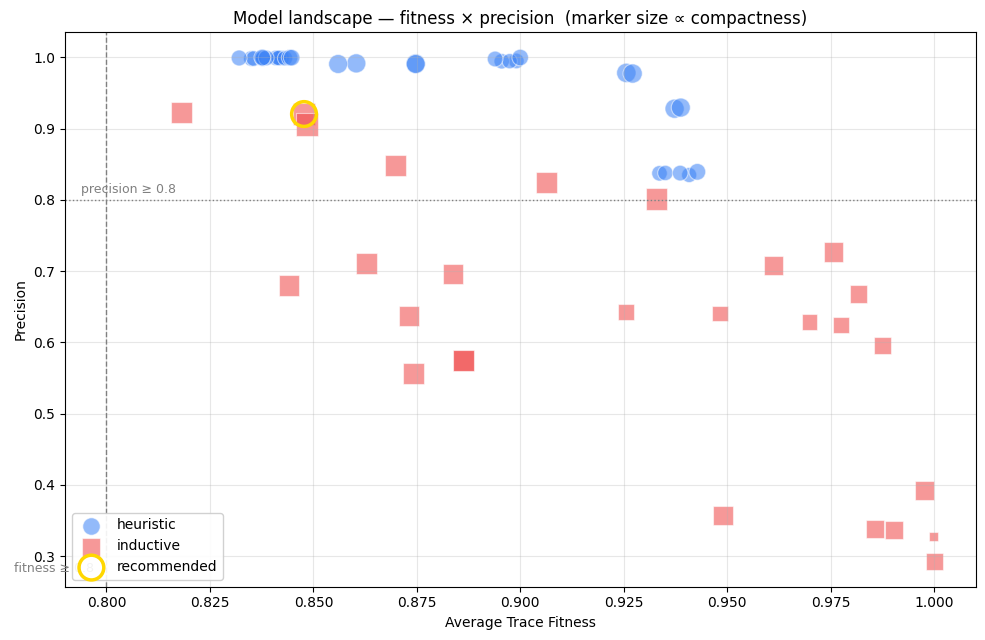

In [ ]:

# ---- Config ----
RESULTS_DIR = Path("/../../results")          # notebook lives in /notebooks
OUTPUT_CSV  = Path("/../../results/model_comparison.csv")

RESULTS_FILES = {
    ("heuristic", "top100"):       "heuristics/heuristic_grid_search_results_top100.csv",
    ("heuristic", "top282"):       "heuristics/heuristic_grid_search_results_top282.csv",
    ("inductive", "all_variants"): "inductive/inductive_grid_search_results_all_variants.csv",
    ("inductive", "top100"):       "inductive/inductive_grid_search_results_top100.csv",
    ("inductive", "top610"):       "inductive/inductive_grid_search_results_top610.csv",
}

# Quality gates -- both fitness and precision must be at least this high.
MIN_PRECISION  = 0.80
MIN_FITNESS    = 0.80

# Scoring weights (1.0 = no penalty, larger = harsher).
INDUCTIVE_BONUS  = 1.00   # 1.0 = pure metrics, 1.2 = strong structural preference
CYCLICITY_WEIGHT = 0.25   # penalty per unit cyclicity; cyclicity=1 -> factor 0.75
SIZE_WEIGHT      = 0.15   # penalty on normalized total size; largest model -> 0.85

DISPLAY_COLS = [
    "Model Name", "Algorithm", "Variant Filter",
    "Average Trace Fitness", "Precision", "Generalization",
    "F-Score", "Cyc Factor", "Size Factor", "DM Score",
    "Node Size", "Arc Size", "Cyclicity",
]

# ---- Load every CSV into one long-form table ----
dfs = []
for (algo, variant), rel_path in RESULTS_FILES.items():
    full = RESULTS_DIR / rel_path
    if not full.exists():
        print(f"[skip] not found: {full}")
        continue
    df = pd.read_csv(full)
    df.insert(0, "Algorithm", algo)
    df.insert(1, "Variant Filter", variant)
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(raw)} rows across "
      f"{raw.groupby(['Algorithm','Variant Filter']).ngroups} log slices")

# ---- Score ----
fit, prec = raw["Average Trace Fitness"], raw["Precision"]

# Primary signal: harmonic mean of fitness and precision.
raw["F-Score"] = np.where(fit + prec > 0, 2 * fit * prec / (fit + prec), 0.0)

# Quality gates.
raw["Low Precision"] = prec < MIN_PRECISION
raw["Low Fitness"]   = fit  < MIN_FITNESS

# Cyclicity factor: gentle penalty for loop-heavy models.
raw["Cyc Factor"]  = 1 - CYCLICITY_WEIGHT * raw["Cyclicity"]

# Size factor: normalise total (nodes + arcs) across all loaded models so the
# scale is stable regardless of which gate-passers we end up with.
raw["Total Size"] = raw["Node Size"] + raw["Arc Size"]
size_span         = raw["Total Size"].max() - raw["Total Size"].min()
raw["Size Norm"]  = (raw["Total Size"] - raw["Total Size"].min()) / (size_span or 1)
raw["Size Factor"] = 1 - SIZE_WEIGHT * raw["Size Norm"]

# Composite score (NaN for disqualified models).
algo_factor = np.where(raw["Algorithm"] == "inductive", INDUCTIVE_BONUS, 1.0)
raw["DM Score"] = np.where(
    raw["Low Precision"] | raw["Low Fitness"],
    np.nan,
    raw["F-Score"] * algo_factor * raw["Cyc Factor"] * raw["Size Factor"],
)

# ---- Dedup equivalent rows (heuristic loop thresholds often produce identical models) ----
dedup_keys = ["Algorithm", "Variant Filter", "Average Trace Fitness", "Precision",
              "Node Size", "Arc Size", "Cyclicity"]
deduped   = raw.sort_values("Model Name").drop_duplicates(subset=dedup_keys, keep="first")
qualified = deduped.dropna(subset=["DM Score"])

display(Markdown(
    f"**Gates:** precision ≥ {MIN_PRECISION}, fitness ≥ {MIN_FITNESS} &nbsp;&nbsp; "
    f"**Weights:** inductive×{INDUCTIVE_BONUS}, cyclicity={CYCLICITY_WEIGHT}, size={SIZE_WEIGHT}"
))
display(Markdown(
    f"**Filtering:** {len(deduped)} unique models &nbsp;|&nbsp; "
    f"{raw['Low Precision'].sum()} disqualified for low precision &nbsp;|&nbsp; "
    f"{raw['Low Fitness'].sum()} disqualified for low fitness &nbsp;|&nbsp; "
    f"**{len(qualified)} qualified for ranking**"
))

# ---- Top 10 leaderboard ----
display(Markdown("## Top 10 by decision-mining suitability"))
top10 = qualified.nlargest(10, "DM Score")[DISPLAY_COLS]
numeric_cols = ["Average Trace Fitness", "Precision", "Generalization",
                "F-Score", "Cyc Factor", "Size Factor", "DM Score", "Cyclicity"]
display(
    top10.style
         .format({c: "{:.4f}" for c in numeric_cols})
         .background_gradient(subset=["DM Score"], cmap="Greens")
         .hide(axis="index")
)

# ---- Best per (algorithm, variant) slice ----
display(Markdown("## Best per (algorithm, variant filter)"))
for (algo, variant), grp in qualified.groupby(["Algorithm", "Variant Filter"]):
    display(Markdown(f"**{algo} / {variant}**"))
    display(grp.nlargest(3, "DM Score")[DISPLAY_COLS].reset_index(drop=True))

# ---- Recommendation ----
display(Markdown("## Recommended final model"))
if qualified.empty:
    display(Markdown("⚠️ **No model passed quality gates.** "
                     "Loosen `MIN_PRECISION` / `MIN_FITNESS` or revisit discovery."))
    winner = None
else:
    winner = qualified.nlargest(1, "DM Score").iloc[0]
    runner_up = qualified.nlargest(2, "DM Score").iloc[-1] if len(qualified) > 1 else None
    md = f"""
| Field | Value |
|---|---|
| **Model** | `{winner['Model Name']}` |
| Algorithm | `{winner['Algorithm']}` on `{winner['Variant Filter']}` |
| Fitness | {winner['Average Trace Fitness']:.4f} |
| Precision | {winner['Precision']:.4f} |
| Generalization | {winner['Generalization']:.4f} |
| F-Score | {winner['F-Score']:.4f} |
| Cyclicity Factor | {winner['Cyc Factor']:.4f} (cyclicity = {winner['Cyclicity']:.4f}) |
| Size Factor | {winner['Size Factor']:.4f} ({int(winner['Node Size'])} nodes + {int(winner['Arc Size'])} arcs) |
| **DM Score** | **{winner['DM Score']:.4f}** |
"""
    if runner_up is not None:
        md += (f"\n*Runner-up:* `{runner_up['Model Name']}` "
               f"(DM Score {runner_up['DM Score']:.4f}, "
               f"fitness {runner_up['Average Trace Fitness']:.3f}, "
               f"precision {runner_up['Precision']:.3f}, "
               f"cyclicity {runner_up['Cyclicity']:.3f})")
    display(Markdown(md))

# ---- Visualization: fitness vs precision, marker size encoding total model size ----
fig, ax = plt.subplots(figsize=(10, 6.5))
colors = {"heuristic": "#3b82f6", "inductive": "#ef4444"}
markers = {"heuristic": "o", "inductive": "s"}

# Marker size: SMALLER models get LARGER markers (we prefer compact nets).
def marker_size(row):
    return 40 + 220 * (1 - row["Size Norm"])

for algo, grp in deduped.groupby("Algorithm"):
    ax.scatter(grp["Average Trace Fitness"], grp["Precision"],
               c=colors[algo], marker=markers[algo],
               s=grp.apply(marker_size, axis=1),
               label=algo, alpha=0.55, edgecolor="white", linewidth=0.8)

# Quality-gate guides.
ax.axhline(MIN_PRECISION, color="grey", linestyle=":",  linewidth=1)
ax.axvline(MIN_FITNESS,   color="grey", linestyle="--", linewidth=1)
ax.text(MIN_FITNESS - 0.003, ax.get_ylim()[0] + 0.02,
        f" fitness ≥ {MIN_FITNESS}", color="grey", ha="right", fontsize=9)
ax.text(ax.get_xlim()[0] + 0.003, MIN_PRECISION + 0.01,
        f" precision ≥ {MIN_PRECISION}", color="grey", fontsize=9)

# Highlight winner.
if winner is not None:
    ax.scatter(winner["Average Trace Fitness"], winner["Precision"],
               s=marker_size(winner) + 80, facecolors="none", edgecolors="gold",
               linewidth=2.5, label="recommended", zorder=5)

ax.set_xlabel("Average Trace Fitness")
ax.set_ylabel("Precision")
ax.set_title("Model landscape — fitness × precision  (marker size ∝ compactness)")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Persist the full ranked table for downstream use ----
out = raw.sort_values("DM Score", ascending=False, na_position="last")
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUTPUT_CSV, index=False)


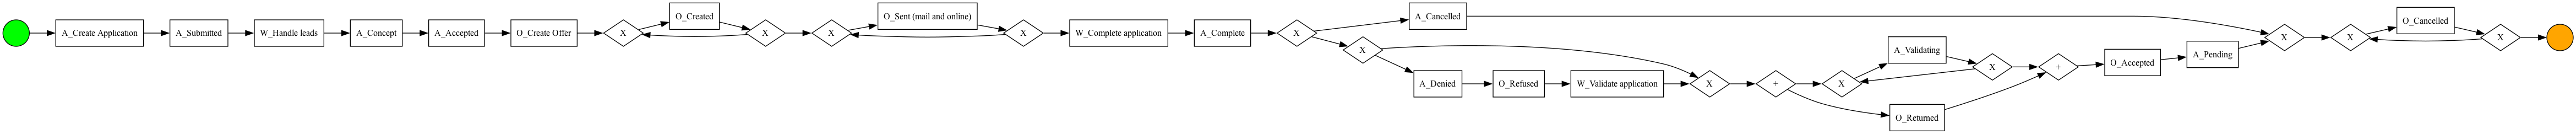

In [14]:
ind_top100_noise09_net, ind_top100_noise09_initial_marking, ind_top100_noise09_final_marking = pm4py.read_pnml("../petrinets/inductive_fine_grid_search_top100/ind_top100_noise_0.90.pnml")
ind_top100_noise09_tree = pm4py.convert_to_process_tree(ind_top100_noise09_net, ind_top100_noise09_initial_marking, ind_top100_noise09_final_marking)
inductive_bpmn_graph = pm4py.convert_to_bpmn(ind_top100_noise09_tree)
pm4py.view_bpmn(inductive_bpmn_graph)

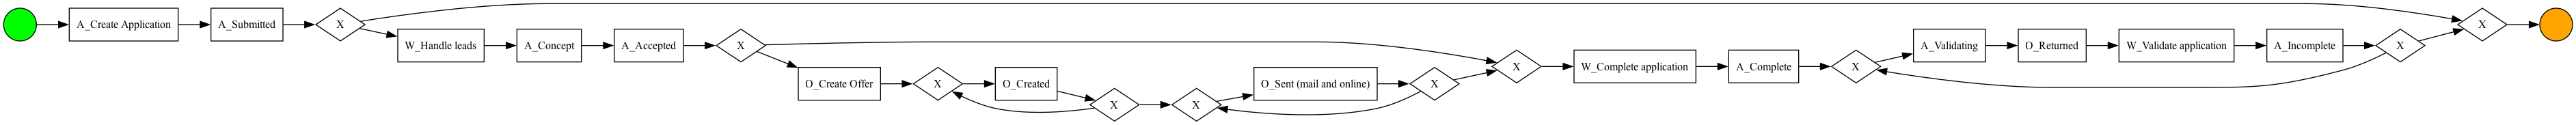

In [15]:
ind_top610_noise09_net, ind_top610_noise09_initial_marking, ind_top610_noise09_final_marking = pm4py.read_pnml("../petrinets/inductive_fine_grid_search_top610/ind_top610_noise_0.90.pnml")
ind_top610_noise09_tree = pm4py.convert_to_process_tree(ind_top610_noise09_net, ind_top610_noise09_initial_marking, ind_top610_noise09_final_marking)
inductive_bpmn_graph = pm4py.convert_to_bpmn(ind_top610_noise09_tree)
pm4py.view_bpmn(inductive_bpmn_graph)

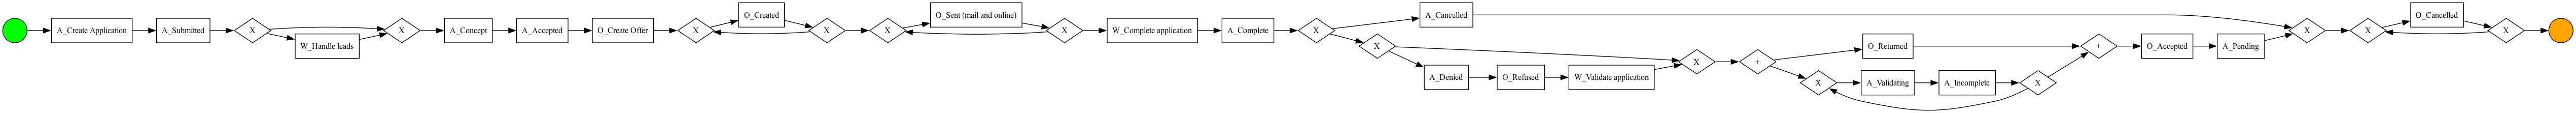

In [16]:
ind_top100_noise06_net, ind_top100_noise06_initial_marking, ind_top100_noise06_final_marking = pm4py.read_pnml("../petrinets/inductive_fine_grid_search_top100/ind_top100_noise_0.60.pnml")
ind_top100_noise06_tree = pm4py.convert_to_process_tree(ind_top100_noise06_net, ind_top100_noise06_initial_marking, ind_top100_noise06_final_marking)
inductive_bpmn_graph = pm4py.convert_to_bpmn(ind_top100_noise06_tree)
pm4py.view_bpmn(inductive_bpmn_graph)